[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AveriX26/ML-Course-2026/blob/main/zad_dom2.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(0)
# Głowa
mean1, cov1 = [0.0, 0.0], [[0.16, 0.0], [0.0, 0.16]]
data1 = np.random.multivariate_normal(mean1, cov1, 300)
# Prawe ucho
mean2, cov2 = [0.8, 0.8], [[0.04, 0.0], [0.0, 0.04]]
data2 = np.random.multivariate_normal(mean2, cov2, 100)
# Lewe ucho
mean3, cov3 = [-0.8, 0.8], [[0.04, 0.0], [0.0, 0.04]]
data3 = np.random.multivariate_normal(mean3, cov3, 100)

X = np.vstack([data1, data2, data3])

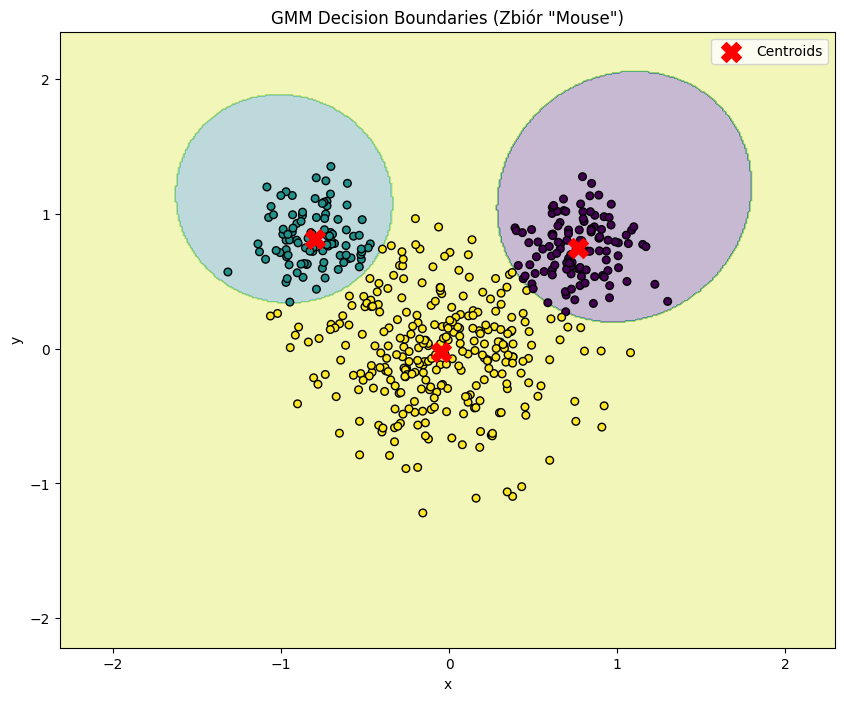

In [ ]:
# Trenowanie modelu GMM
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
labels = gmm.predict(X)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = gmm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30, edgecolor='k', cmap='viridis')
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], color='red', marker='X', s=200, label='Centroids')

plt.title('GMM Decision Boundaries (Zbiór "Mouse")')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Primary Question: Decision Boundary and Irregularities

Aby zwizualizować granice decyzyjne dla nowych punktów, zastosowano mapę kolorów (contour map) rozciągniętą na gęstej siatce punktów wokół naszych danych. Dla każdego punktu siatki model GMM wyznaczył najbardziej prawdopodobny klaster, co ukazuje kształt obszarów decyzyjnych.

**Zaobserwowane nieregularności:**
Na wygenerowanym wykresie można zaobserwować bardzo nieintuicyjne zjawisko. Obszary przypisane do "uszu" (dwa mniejsze klastry z góry) są całkowicie zamknięte i tworzą "wyspy". Oznacza to, że punkty leżące na zewnątrz tych wysp są przypisywane do klastra "głowy" (centralnego). 

Analiza numeryczna potwierdza to zjawisko: jeśli weźmiemy punkt znajdujący się daleko w prawym górnym rogu, np. `[5.0, 5.0]`, który geometrycznie jest znacznie bliżej prawego "ucha", GMM przypisze go do klastra "głowy" z prawdopodobieństwem $1.0$ ($100\%$). Prawdopodobieństwo przynależności do klastra "ucha" wynosi dla tego punktu zaledwie rzędu $10^{-269}$.

**Dlaczego tak się dzieje?**
Wynika to z faktu, że algorytm EM używa prawdopodobieństwa a posteriori (zależnego m.in. od macierzy kowariancji $\Sigma$), a nie zwykłej odległości euklidesowej. Centralny klaster ("głowa") charakteryzuje się znacznie większą wariancją (0.16) niż klastry "uszu" (0.04). 

Zgodnie ze wzorem na wielowymiarowy rozkład normalny:
$$P(x|\mu, \Sigma) \propto \exp\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right)$$
Prawdopodobieństwo dla klastrów o małej wariancji ("uszy") opada do zera ekstremalnie szybko w miarę oddalania się od ich środka. Z kolei rozkład klastra centralnego ma tzw. "cięższe ogony" – opada wolniej. W związku z tym, w dużej odległości od wszystkich środków ciężkości (centroidów), to właśnie powoli malejące prawdopodobieństwo klastra z dużą wariancją dominuje nad szybko malejącym prawdopodobieństwem klastrów z małą wariancją. Model uznaje odległy punkt za ekstremalną wartość odstającą dużej "głowy", a nie małego "ucha".

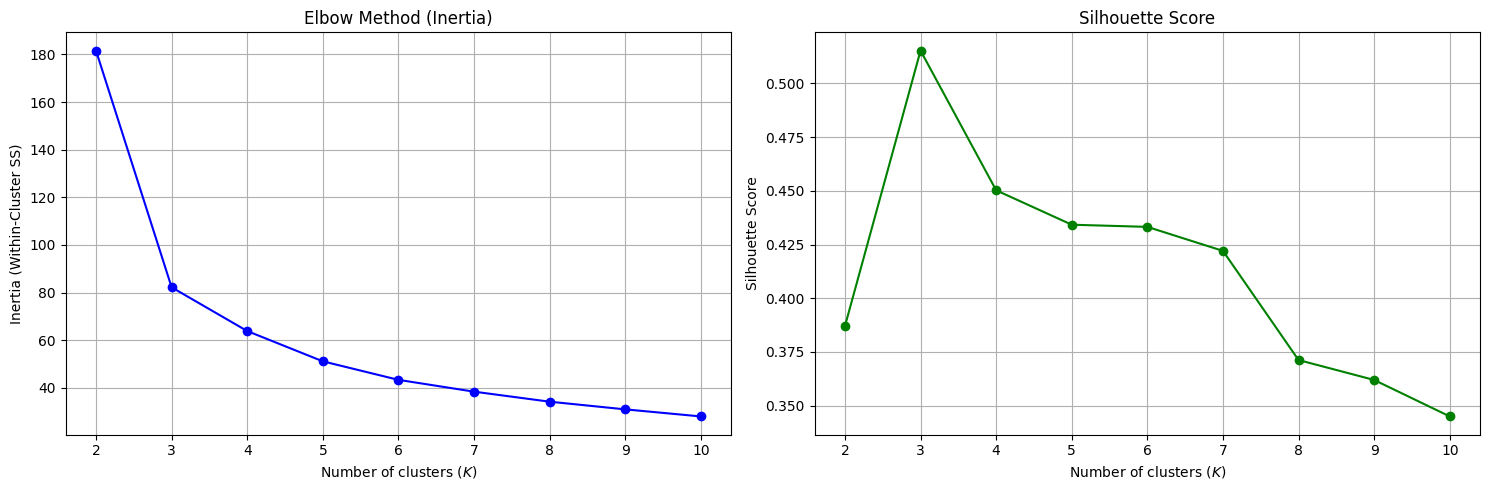

In [ ]:
inertia_values = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertia_values, marker='o', linestyle='-', color='b')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of clusters ($K$)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_xticks(K_range)
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, marker='o', linestyle='-', color='g')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters ($K$)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(K_range)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Secondary Question: Deciding on a Suitable $K$

Jeśli nie znalibyśmy z góry liczby klastrów w naszym zbiorze danych, moglibyśmy określić odpowiednie $K$ korzystając z numerycznych metryk ewaluacji jakości grupowania. Przetestowano różne wartości $K$ (od 2 do 10) przy użyciu algorytmu K-Means i przeanalizowano dwa kluczowe wskaźniki:

1. **Metoda Łokcia (Inertia):**
   Inercja mierzy zwartość klastrów (compactness) jako sumę kwadratów odległości punktów od ich centroidów. Obserwując wartości Inercji w zależności od $K$, szukamy tzw. "łokcia" – punktu, w którym tempo spadku inercji gwałtownie maleje. 
   Z naszych wyliczeń wynika, że przy przejściu z $K=2$ na $K=3$ inercja drastycznie spada. Przy dalszym zwiększaniu klastrów  spadek jest już znacznie łagodniejszy i przynosi minimalne korzyści. Wskazuje to na "łokieć" w punkcie $K=3$.

2. **Współczynnik Sylwetki (Silhouette Score):**
   Metryka Silhouette mierzy zarówno zwartość wewnątrz klastrów (compactness), jak i separację od klastrów sąsiednich. Przyjmuje ona wartości z zakresu $[-1, 1]$, gdzie wyższa wartość oznacza lepsze dopasowanie. 
   Nasze testy jednoznacznie pokazują, że najwyższy wynik Silhouette Score osiągany jest dla $K=3$. Oznacza to, że przy podziale na 3 grupy punkty są optymalnie przypisane do swoich własnych klastrów i najlepiej oddzielone od innych.

**Wniosek:** Zarówno a Inercji, jak i punkt szczytowy wartości Silhouette Score w sposób jednoznaczny i obiektywny wskazują, że $K=3$ jest najbardziej odpowiednią liczbą klastrów dla tego zbioru danych.